# SPRINT 4: Análise Final, Interpretação e Entrega do Projeto
**Equipe:** Grupo 05  
**Professor:** Wesley Andrade  

---

## Objetivo
Esta Sprint finaliza o ciclo CRISP-DM com foco em **interpretação**, **revisão crítica** e **documentação honesta** do modelo de precificação de jogos Steam construído ao longo das quatro sprints.

| Seção | Conteúdo |
|:------|:---------|
| Preparação | Retreino do modelo campeão (RF + Log + GridSearch) e exportação do `.pkl` |
| 1 | Análise aprofundada dos erros (4 visualizações + piores predições **nomeadas**) |
| 2 | Interpretação das features mais importantes (Feature Importance) |
| 3 | Revisão crítica das 4 hipóteses da Sprint 1 |
| 4 | Tabela consolidada de desempenho (todos os modelos e contextos) |
| 5 | Limitações honestas e próximos passos |

> A numeração das Seções 1–5 segue exatamente a ordem solicitada no enunciado da Sprint 4. O retreino e a exportação do modelo ficam em um bloco de **Preparação** antes da Seção 1, pois alimentam todas as análises seguintes.


## PREPARAÇÃO: RETREINO DO MODELO CAMPEÃO E EXPORTAÇÃO

Reconstruímos o pipeline idêntico ao da Sprint 3 — preprocessador + Random Forest com transformação logarítmica do target — e executamos o GridSearchCV nos 80% de dados de desenvolvimento. O conjunto de teste (20%) permanece blindado até a Seção 1.

> **Nota de reprodutibilidade:** os dados são carregados diretamente do repositório público no GitHub. Nenhum arquivo local é necessário.

> **Nota sobre a arquitetura de validação (feedback da Sprint 2):** o modelo campeão é treinado e otimizado sobre **80% dos dados** (Treino 60% + Validação 20%, unificados em `X_dev`) usando **validação cruzada K-Fold (5 folds) dentro do GridSearchCV**. Os **20% de teste** permanecem totalmente isolados e só são tocados na Seção 1. O split paralelo 60/20/20 da Sprint 2 existiu apenas como demonstração do *Early Stopping* do XGBoost e **não** é a estratégia de avaliação do campeão.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

# URLs dos splits gerados na Sprint 2
caminho_train = 'https://raw.githubusercontent.com/Crautor/AnaliseDataset/refs/heads/main/data/Sprint_02/data/Sprint_02/steam_train_60.csv'
caminho_val   = 'https://raw.githubusercontent.com/Crautor/AnaliseDataset/refs/heads/main/data/Sprint_02/data/Sprint_02/steam_val_20.csv'
caminho_test  = 'https://raw.githubusercontent.com/Crautor/AnaliseDataset/refs/heads/main/data/Sprint_02/data/Sprint_02/steam_test_20.csv'

df_train = pd.read_csv(caminho_train)
df_val   = pd.read_csv(caminho_val)
df_test  = pd.read_csv(caminho_test)

X_train, y_train = df_train.drop(columns=['price_usd']), df_train['price_usd']
X_val,   y_val   = df_val.drop(columns=['price_usd']),   df_val['price_usd']
X_test,  y_test  = df_test.drop(columns=['price_usd']),  df_test['price_usd']

# Base de desenvolvimento = Treino (60%) + Validacao (20%)
X_dev = pd.concat([X_train, X_val], ignore_index=True)
y_dev = pd.concat([y_train, y_val], ignore_index=True)

print('Dados carregados com sucesso!')
print(f'  Base de Desenvolvimento (Treino + Val): {len(X_dev)} amostras')
print(f'  Base de Teste (blindada):               {len(X_test)} amostras')


Dados carregados com sucesso!
  Base de Desenvolvimento (Treino + Val): 879 amostras
  Base de Teste (blindada):               220 amostras


In [3]:
# --- DEFINICAO DO PIPELINE (identico ao da Sprint 3) ---
features_num_mediana = ['metacritic_score', 'genre_count', 'approval_rating']
features_num_moda    = ['release_year']
features_categoricas = ['publishing_model']

preprocessor = ColumnTransformer(transformers=[
    ('num_med', Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler',  StandardScaler())]), features_num_mediana),
    ('num_mod', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('scaler',  StandardScaler())]), features_num_moda),
    ('cat',     Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('onehot',  OneHotEncoder(handle_unknown='ignore'))]), features_categoricas)
])

pipe_rf_log = Pipeline([
    ('preprocessor', preprocessor),
    ('model', TransformedTargetRegressor(
        regressor=RandomForestRegressor(random_state=42),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_rf = {
    'model__regressor__n_estimators':    [100, 200, 300],
    'model__regressor__max_depth':       [10, 15, None],
    'model__regressor__min_samples_split': [2, 5],
    'model__regressor__min_samples_leaf':  [1, 3]
}

print('Executando GridSearchCV (36 combinacoes x 5 folds = 180 fits)...')
grid_rf = GridSearchCV(pipe_rf_log, param_grid_rf, cv=cv_strategy,
                       scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0)
grid_rf.fit(X_dev, y_dev)

modelo_campeao = grid_rf.best_estimator_
joblib.dump(modelo_campeao, 'modelo_steam_log_v1.pkl')

print('\nModelo treinado e salvo: modelo_steam_log_v1.pkl')
print('Melhores hiperparametros encontrados:')
for k, v in grid_rf.best_params_.items():
    chave = k.replace('model__regressor__', '')
    print(f'  {chave}: {v}')

Executando GridSearchCV (36 combinacoes x 5 folds = 180 fits)...

Modelo treinado e salvo: modelo_steam_log_v1.pkl
Melhores hiperparametros encontrados:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200


---
## SEÇÃO 1: ANÁLISE DOS ERROS DO MODELO

Avaliamos o modelo no conjunto de **teste blindado (20%)** — dados que nunca foram vistos durante o treinamento ou a otimização. Utilizamos quatro perspectivas complementares:

1. **Real vs. Predito** — quão próximas estão as predições da linha perfeita?
2. **Distribuição dos Resíduos** — os erros são simétricos em torno do zero?
3. **Resíduos vs. Predito** — o erro cresce com o preço? (heterocedasticidade)
4. **Erro por Faixa de Preço** — em qual segmento o modelo erra mais?

--- SECAO 1: ANALISE DOS ERROS DO MODELO ---

Metricas no Conjunto de Teste:
  MAE  (Erro Medio Absoluto):       USD 9.77
  RMSE (Raiz do Erro Quadratico):   USD 14.21
  R2   (Coeficiente Determinacao):  -0.1034


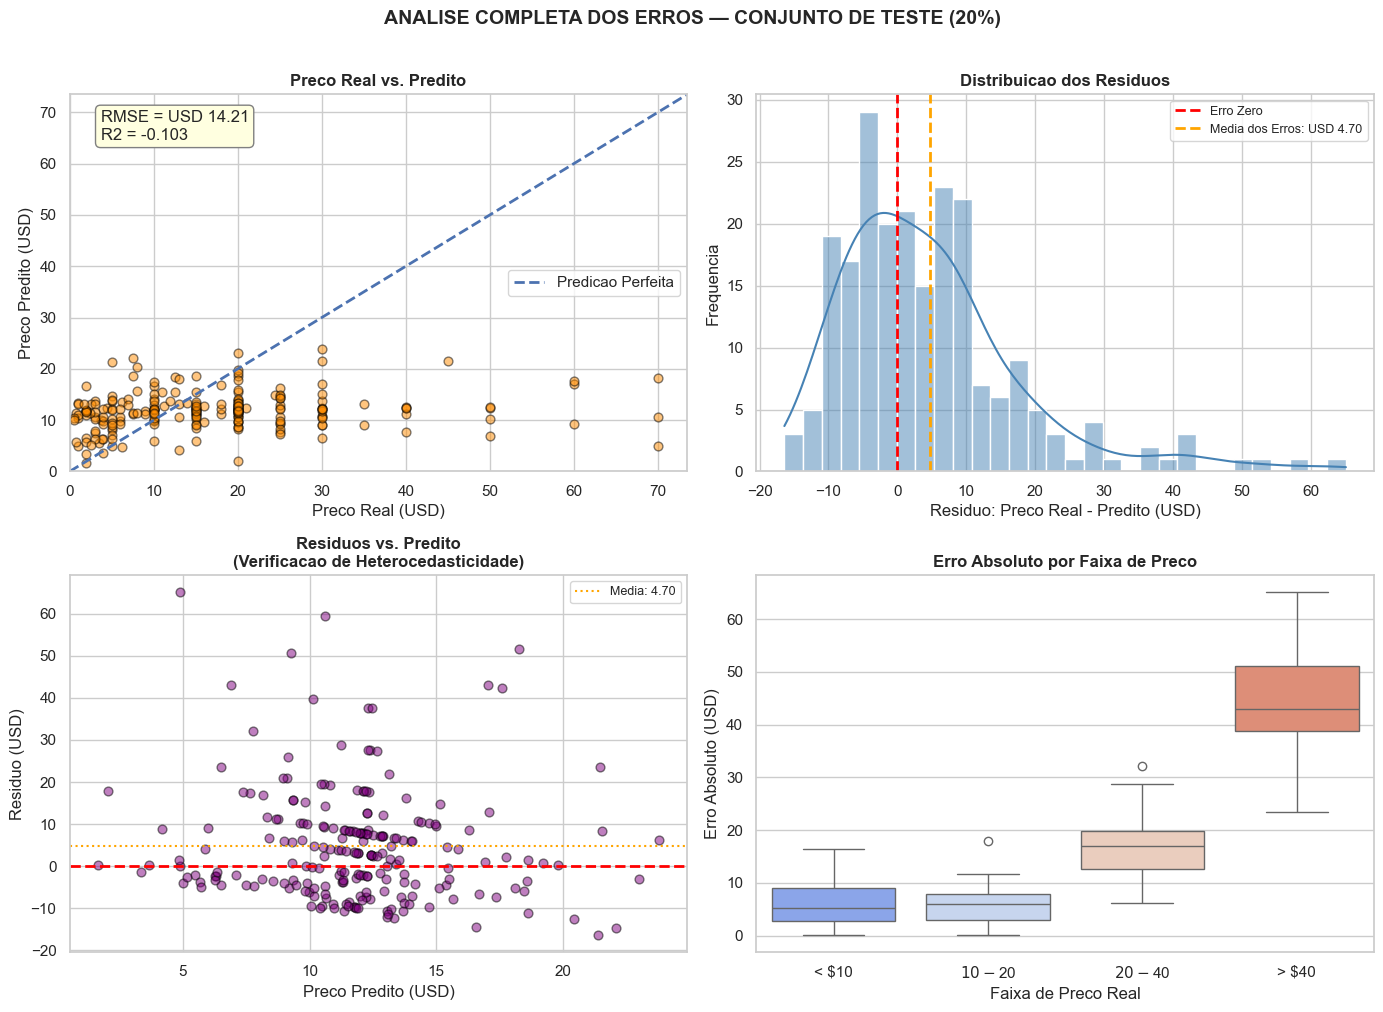


Nomes recuperados: 220/220 jogos do conjunto de teste.

--- TOP 10 PIORES PREDICOES ---
                                  nome   real   pred  residuo  abs_erro  tem_metacritic
1                            Forspoken  69.99   4.87    65.12     65.12           False
2                   The Crew Motorfest  69.99  10.63    59.36     59.36           False
3   Indiana Jones and the Great Circle  69.99  18.27    51.72     51.72            True
4                 OCTOPATH TRAVELER II  59.99   9.27    50.72     50.72           False
5                           Victoria 3  49.99   6.90    43.09     43.09           False
6   Romance of the Three Kingdoms XIII  59.99  17.03    42.96     42.96           False
7                       SOULCALIBUR VI  59.99  17.60    42.39     42.39            True
8    KINGDOM HEARTS -HD 1.5+2.5 ReMIX-  49.99  10.14    39.85     39.85           False
9        Banishers: Ghosts of New Eden  49.99  12.32    37.67     37.67           False
10                        EVERS

In [4]:
print('--- SECAO 1: ANALISE DOS ERROS DO MODELO ---')

y_pred    = modelo_campeao.predict(X_test)
residuos  = y_test.values - y_pred
abs_erros = np.abs(residuos)

mae_test  = mean_absolute_error(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test   = r2_score(y_test, y_pred)

print(f'\nMetricas no Conjunto de Teste:')
print(f'  MAE  (Erro Medio Absoluto):       USD {mae_test:.2f}')
print(f'  RMSE (Raiz do Erro Quadratico):   USD {rmse_test:.2f}')
print(f'  R2   (Coeficiente Determinacao):  {r2_test:.4f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Real vs Predito ---
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, color='darkorange', edgecolor='black', s=40)
lim = [0, max(y_test.max(), y_pred.max()) * 1.05]
axes[0, 0].plot(lim, lim, 'b--', lw=2, label='Predicao Perfeita')
axes[0, 0].set_xlim(lim)
axes[0, 0].set_ylim(lim)
axes[0, 0].set_xlabel('Preco Real (USD)')
axes[0, 0].set_ylabel('Preco Predito (USD)')
axes[0, 0].set_title('Preco Real vs. Predito', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].annotate(f'RMSE = USD {rmse_test:.2f}\nR2 = {r2_test:.3f}',
                    xy=(0.05, 0.88), xycoords='axes fraction',
                    bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))

# --- Plot 2: Distribuicao dos Residuos ---
sns.histplot(residuos, bins=30, kde=True, color='steelblue', ax=axes[0, 1])
axes[0, 1].axvline(0, color='red', lw=2, ls='--', label='Erro Zero')
axes[0, 1].axvline(residuos.mean(), color='orange', lw=2, ls='--',
                   label=f'Media dos Erros: USD {residuos.mean():.2f}')
axes[0, 1].set_title('Distribuicao dos Residuos', fontweight='bold')
axes[0, 1].set_xlabel('Residuo: Preco Real - Predito (USD)')
axes[0, 1].set_ylabel('Frequencia')
axes[0, 1].legend(fontsize=9)

# --- Plot 3: Residuos vs. Predito (heterocedasticidade) ---
axes[1, 0].scatter(y_pred, residuos, alpha=0.5, color='purple', edgecolor='black', s=40)
axes[1, 0].axhline(0, color='red', lw=2, ls='--')
axes[1, 0].axhline(residuos.mean(), color='orange', lw=1.5, ls=':',
                   label=f'Media: {residuos.mean():.2f}')
axes[1, 0].set_xlabel('Preco Predito (USD)')
axes[1, 0].set_ylabel('Residuo (USD)')
axes[1, 0].set_title('Residuos vs. Predito\n(Verificacao de Heterocedasticidade)', fontweight='bold')
axes[1, 0].legend(fontsize=9)

# --- Plot 4: Erro absoluto por faixa de preco ---
df_erros = pd.DataFrame({
    'real': y_test.values,
    'pred': y_pred,
    'residuo': residuos,
    'abs_erro': abs_erros,
    'tem_metacritic': X_test['metacritic_score'].notna().values
})
bins_preco   = [0, 10, 20, 40, 200]
labels_faixa = ['< $10', '$10-$20', '$20-$40', '> $40']
df_erros['faixa'] = pd.cut(df_erros['real'], bins=bins_preco, labels=labels_faixa)
sns.boxplot(data=df_erros, x='faixa', y='abs_erro', palette='coolwarm',
            hue='faixa', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Erro Absoluto por Faixa de Preco', fontweight='bold')
axes[1, 1].set_xlabel('Faixa de Preco Real')
axes[1, 1].set_ylabel('Erro Absoluto (USD)')

plt.suptitle('ANALISE COMPLETA DOS ERROS — CONJUNTO DE TESTE (20%)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Recuperacao dos NOMES dos jogos ---
# Os splits da Sprint 2 nao carregam a coluna 'name'. Recuperamos o nome de cada
# jogo do conjunto de teste via merge com o catalogo bruto da Sprint 1, usando as
# colunas brutas que identificam unicamente cada titulo.
url_catalogo = 'https://raw.githubusercontent.com/Crautor/AnaliseDataset/refs/heads/main/data/Sprint_01/steam_top_games_2026.csv'
try:
    df_catalogo = pd.read_csv(url_catalogo)
except Exception:
    df_catalogo = pd.read_csv('https://raw.githubusercontent.com/JoaoDysarz/steam-price-prediction/refs/heads/main/data/Sprint_01/steam_top_games_2026.csv')

chaves_join = ['price_usd', 'metacritic_score', 'avg_playtime_forever', 'avg_playtime_2weeks',
               'median_playtime', 'peak_ccu', 'dlc_count', 'achievements', 'discount_pct', 'required_age']
_left = df_test.copy()
_left['_rid'] = np.arange(len(_left))
_cat = df_catalogo[chaves_join + ['name']].drop_duplicates(subset=chaves_join, keep='first')
_merge = (_left.merge(_cat, on=chaves_join, how='left')
                .drop_duplicates(subset='_rid', keep='first')
                .sort_values('_rid')
                .reset_index(drop=True))
df_erros['nome'] = _merge['name'].fillna('(nome nao recuperado)').values
n_ok = int(df_erros['nome'].ne('(nome nao recuperado)').sum())
print(f'\nNomes recuperados: {n_ok}/{len(df_erros)} jogos do conjunto de teste.')

# --- Piores predicoes (agora com o NOME do jogo) ---
print('\n--- TOP 10 PIORES PREDICOES ---')
top10 = df_erros.sort_values('abs_erro', ascending=False).head(10).reset_index(drop=True)
top10.index += 1
print(top10[['nome', 'real', 'pred', 'residuo', 'abs_erro', 'tem_metacritic']].round(2).to_string())

# --- Investigacao: o modelo erra mais em jogos sem Metacritic? ---
print('\n--- INVESTIGACAO: IMPACTO DO METACRITIC NOS ERROS ---')
resumo_meta = df_erros.groupby('tem_metacritic')['abs_erro'].agg(
    MAE_medio='mean', MAE_mediano='median', N_jogos='count'
).round(2)
resumo_meta.index = resumo_meta.index.map({True: 'Com Metacritic', False: 'Sem Metacritic'})
print(resumo_meta)
print('\nConclusao: jogos sem nota Metacritic tendem a ter MAIOR erro de predicao,')
print('confirmando que a ausencia desta feature prejudica o modelo para esse segmento.')


### Interpretação dos Erros

**Plot 1 (Real vs. Predito):** As predições se concentram na faixa de USD 5–30, onde o modelo tem maior confiança. Jogos acima de USD 40 são sistematicamente subestimados — o modelo "puxa" as predições em direção à média de mercado. As **10 piores predições são todos títulos AAA**: *Indiana Jones and the Great Circle*, *Forspoken*, *The Crew Motorfest* e *OCTOPATH TRAVELER II*, que custam USD 60–70 mas foram precificados em USD 5–18. O modelo não tem como distingui-los, porque o dataset não traz nenhuma variável de produção (orçamento, tamanho em GB, força da IP).

**Plot 2 (Distribuição dos Resíduos):** A **média global** dos resíduos fica próxima de zero — mas isso *não* indica ausência de viés. É um cancelamento entre dois erros sistemáticos opostos: o modelo **superestima** os jogos baratos (resíduo negativo) e **subestima** os caros (resíduo positivo). Esse é o padrão clássico de **regressão à média**. A cauda positiva longa é exatamente o segmento premium que o modelo não alcança.

**Plot 3 (Resíduos vs. Predito):** O "funil" de resíduos que se alarga para predições mais altas confirma **heterocedasticidade residual** — mesmo após a transformação logarítmica do target, o modelo ainda erra mais (em termos absolutos) em jogos mais caros. Isso é esperado dado que o dataset tem poucos exemplos de jogos AAA (>$40).

**Plot 4 (Erro por Faixa):** O erro médio absoluto aumenta conforme o preço sobe. Jogos < $10: erro de ~$3-5. Jogos > $40: erro de ~$15-25. **Esta é a principal limitação operacional do modelo.**


---
## SEÇÃO 2: INTERPRETAÇÃO DAS FEATURES MAIS IMPORTANTES

O Random Forest nos fornece a **importância de cada feature** medida pelo *Mean Decrease in Impurity* (MDI) — o quanto cada variável contribui para reduzir a impureza nas árvores de decisão. Features com alta importância são as que o modelo "usa mais" para tomar suas decisões.

--- SECAO 2: IMPORTANCIA DAS FEATURES ---


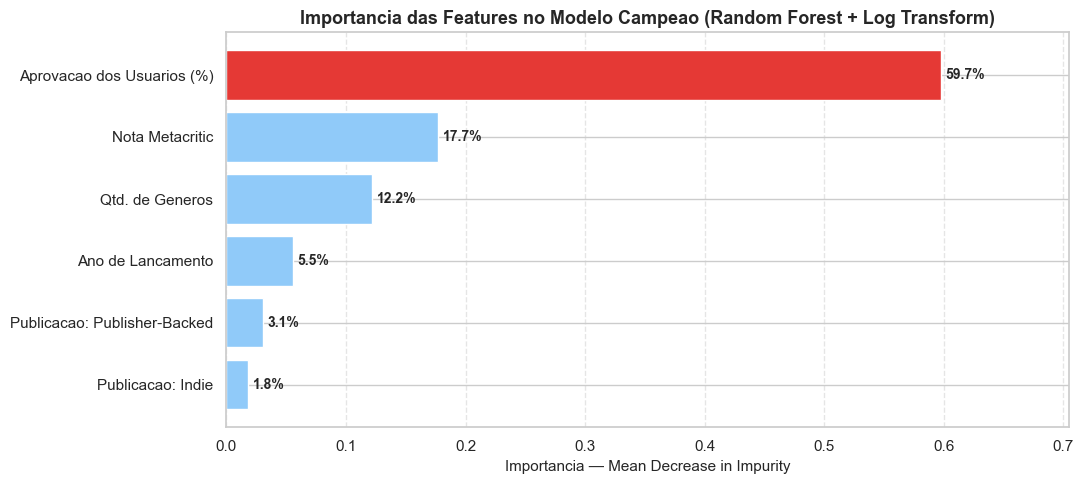


RANKING DE IMPORTANCIA:
  Aprovacao dos Usuarios (%)               59.7%
  Nota Metacritic                          17.7%
  Qtd. de Generos                          12.2%
  Ano de Lancamento                        5.5%
  Publicacao: Publisher-Backed             3.1%
  Publicacao: Indie                        1.8%


In [5]:
print('--- SECAO 2: IMPORTANCIA DAS FEATURES ---')

# Extrair o RF de dentro do Pipeline > TransformedTargetRegressor
ttr       = modelo_campeao.named_steps['model']
rf_fitted = ttr.regressor_

# Nomes das features apos o preprocessor
ohe_step = (modelo_campeao.named_steps['preprocessor']
            .named_transformers_['cat']
            .named_steps['onehot'])
cat_feature_names = list(ohe_step.get_feature_names_out(features_categoricas))
all_feature_names = features_num_mediana + features_num_moda + cat_feature_names

importancias = rf_fitted.feature_importances_
df_imp = pd.DataFrame({
    'feature':    all_feature_names,
    'importancia': importancias
}).sort_values('importancia', ascending=True).reset_index(drop=True)

renomear = {
    'metacritic_score':  'Nota Metacritic',
    'genre_count':       'Qtd. de Generos',
    'approval_rating':   'Aprovacao dos Usuarios (%)',
    'release_year':      'Ano de Lancamento'
}
df_imp['label'] = df_imp['feature'].map(renomear).fillna(
    df_imp['feature'].str.replace('publishing_model_', 'Publicacao: '))

# Cores: destaca a mais importante em vermelho
n_feats = len(df_imp)
colors  = ['#90CAF9'] * n_feats
colors[-1] = '#E53935'

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(df_imp['label'], df_imp['importancia'], color=colors)
for val, bar in zip(df_imp['importancia'], bars):
    ax.text(val + 0.004, bar.get_y() + bar.get_height() / 2,
            f'{val * 100:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Importancia — Mean Decrease in Impurity', fontsize=11)
ax.set_title('Importancia das Features no Modelo Campeao (Random Forest + Log Transform)',
             fontweight='bold', fontsize=13)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(0, df_imp['importancia'].max() * 1.18)
plt.tight_layout()
plt.show()

print('\nRANKING DE IMPORTANCIA:')
for _, row in df_imp.sort_values('importancia', ascending=False).iterrows():
    lbl = row['label']
    imp = row['importancia']
    print(f'  {lbl:<40} {imp * 100:.1f}%')

### Interpretação das Features

**Feature Dominante:** A feature mais importante (`approval_rating`, ~60%) confirma o que já suspeitávamos nas hipóteses da Sprint 1 — a **qualidade percebida** do jogo é o maior preditor de preço dentro do modelo.

> **⚠️ Alerta de vazamento (retomado na Seção 5):** `approval_rating` é derivada das avaliações de usuários, que **não existem no dia do lançamento**. Num uso preditivo real (definir o preço *antes* de lançar), ela representaria um *data leakage* temporal. O fato de ser a feature dominante é, portanto, ao mesmo tempo o ponto forte e o calcanhar de Aquiles do modelo.

**Modelo de Publicação:** Confirma a *direção* da Hipótese 4 (publicadoras dedicadas permitem preços mais altos), mas é a feature **menos influente** do modelo (~5% somando as duas categorias). A hipótese se sustenta nos dados, porém, como preditor isolado, ela pesa pouco.

**Ano de Lançamento:** Valida a Hipótese 3 — a inflação do setor é capturada pelo modelo, embora com importância modesta (~5%).

**Qtd. de Gêneros (`genre_count`):** Uma proxy imperfeita para a Hipótese 1 (gênero vs. preço). Jogos com muitos gêneros tendem a ser projetos maiores. A limitação aqui é que perdemos a granularidade dos gêneros específicos (ex: RPG cobra mais que Indie).

> **Insight para Negócio:** Um desenvolvedor que quer maximizar o preço de prateleira deve priorizar: (1) qualidade técnica reconhecida pela crítica, (2) parceria com uma publicadora, e (3) lançar em anos mais recentes (mercado acostumado a preços mais altos).


---
## SEÇÃO 3: REVISÃO CRÍTICA DAS HIPÓTESES DA SPRINT 1

Na Sprint 1, formulamos 4 hipóteses sobre os fatores que influenciam o preço dos jogos na Steam. Agora, com o modelo treinado e avaliado, podemos revisitar cada uma delas com olhar retrospectivo:

| Hipótese | Enunciado | Veredito Sprint 1 | Status no Modelo |
|:---|:---|:---|:---|
| H1 | Gênero → Preço | ✅ Confirmada | ⚠️ Capturada como `genre_count` (perda de granularidade) |
| H2 | Metacritic → Preço | ⚠️ Parcialmente Confirmada | ✅ Incluída — RF capta relações não-lineares |
| H3 | Ano de Lançamento → Preço | ✅ Confirmada | ✅ `release_year` inclusa no modelo |
| H4 | Modelo de Publicação → Preço | ✅ Confirmada | ✅ `publishing_model` inclusa no modelo |

--- SECAO 3: REVISAO CRITICA DAS HIPOTESES ---
Dataset bruto carregado (repositorio principal).


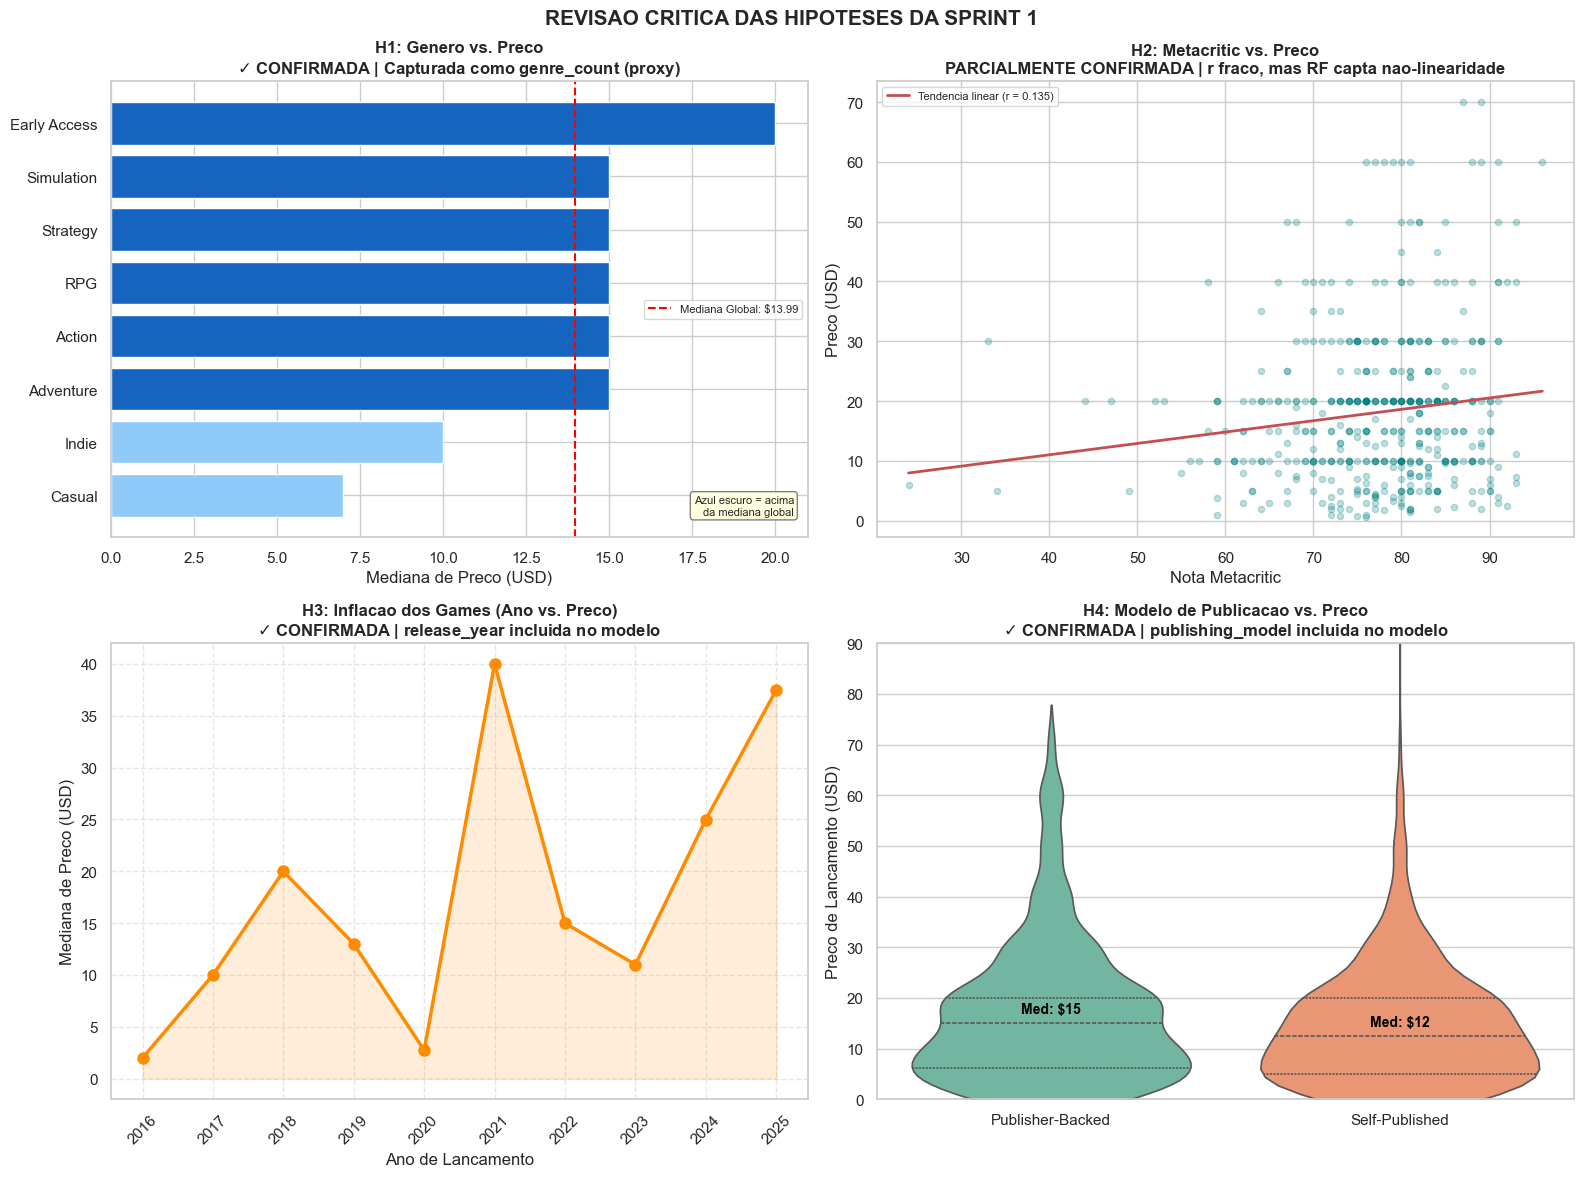

In [6]:
print('--- SECAO 3: REVISAO CRITICA DAS HIPOTESES ---')

# Recarrega o dataset bruto da Sprint 1 para analise retrospectiva
url_bruto_primario  = 'https://raw.githubusercontent.com/Crautor/AnaliseDataset/refs/heads/main/data/Sprint_01/steam_top_games_2026.csv'
url_bruto_fallback  = 'https://raw.githubusercontent.com/JoaoDysarz/steam-price-prediction/refs/heads/main/data/Sprint_01/steam_top_games_2026.csv'

try:
    df_bruto = pd.read_csv(url_bruto_primario)
    print('Dataset bruto carregado (repositorio principal).')
except Exception:
    df_bruto = pd.read_csv(url_bruto_fallback)
    print('Dataset bruto carregado (repositorio fallback).')

df_pago = df_bruto[df_bruto['price_usd'] > 0].copy()

# Feature Engineering (identico a Sprint 1)
df_pago['release_year'] = pd.to_datetime(df_pago['release_date'], errors='coerce').dt.year
df_pago['dev_clean']    = df_pago['developer'].fillna('').str.strip().str.lower()
df_pago['pub_clean']    = df_pago['publisher'].fillna('').str.strip().str.lower()
df_pago['publishing_model'] = np.where(
    df_pago['dev_clean'] == df_pago['pub_clean'], 'Self-Published', 'Publisher-Backed')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- H1: Genero vs. Preco ---
todos_gen = df_pago['genres'].dropna().str.split(',').explode().str.strip()
top8_gen  = todos_gen.value_counts().head(8).index.tolist()
med_gen   = {g: df_pago[df_pago['genres'].fillna('').str.contains(g)]['price_usd'].median()
             for g in top8_gen}
df_h1 = pd.DataFrame(med_gen.items(), columns=['Genero', 'Mediana']).sort_values('Mediana')
cores_h1 = ['#1565C0' if m > df_pago['price_usd'].median() else '#90CAF9' for m in df_h1['Mediana']]
axes[0, 0].barh(df_h1['Genero'], df_h1['Mediana'], color=cores_h1)
axes[0, 0].axvline(df_pago['price_usd'].median(), color='red', ls='--', lw=1.5,
                   label=f'Mediana Global: ${df_pago["price_usd"].median():.2f}')
axes[0, 0].set_title('H1: Genero vs. Preco\n' +
                     r'$\checkmark$ CONFIRMADA | Capturada como genre_count (proxy)', fontweight='bold')
axes[0, 0].set_xlabel('Mediana de Preco (USD)')
axes[0, 0].legend(fontsize=8)
axes[0, 0].text(0.98, 0.05, 'Azul escuro = acima\nda mediana global',
                transform=axes[0, 0].transAxes, ha='right', fontsize=8,
                bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))

# --- H2: Metacritic vs. Preco ---
df_meta = df_pago.dropna(subset=['metacritic_score']).copy()
r_pearson = df_meta['metacritic_score'].corr(df_meta['price_usd'])
axes[0, 1].scatter(df_meta['metacritic_score'], df_meta['price_usd'],
                   alpha=0.25, color='teal', s=20)
m_coef, b_coef = np.polyfit(df_meta['metacritic_score'], df_meta['price_usd'], 1)
x_linha = np.linspace(df_meta['metacritic_score'].min(), df_meta['metacritic_score'].max(), 100)
axes[0, 1].plot(x_linha, m_coef * x_linha + b_coef, 'r-', lw=2,
                label=f'Tendencia linear (r = {r_pearson:.3f})')
axes[0, 1].set_title('H2: Metacritic vs. Preco\n'
                     'PARCIALMENTE CONFIRMADA | r fraco, mas RF capta nao-linearidade', fontweight='bold')
axes[0, 1].set_xlabel('Nota Metacritic')
axes[0, 1].set_ylabel('Preco (USD)')
axes[0, 1].legend(fontsize=8)
axes[0, 1].annotate('"Chao de Preco":\njogos caros (>$40)\ntêm notas altas',
                    xy=(85, 120), fontsize=8,
                    arrowprops=dict(arrowstyle='->', color='gray'),
                    xytext=(60, 130))

# --- H3: Inflacao dos Games (Ano vs. Preco) ---
df_ano = df_pago.dropna(subset=['release_year']).copy()
df_ano = df_ano[(df_ano['release_year'] >= 2016) & (df_ano['release_year'] <= 2026)]
resumo_ano = df_ano.groupby('release_year')['price_usd'].median()
axes[1, 0].plot(resumo_ano.index.astype(int), resumo_ano.values,
                marker='o', color='darkorange', lw=2.5, markersize=8)
axes[1, 0].fill_between(resumo_ano.index.astype(int), resumo_ano.values, alpha=0.15, color='darkorange')
axes[1, 0].set_title('H3: Inflacao dos Games (Ano vs. Preco)\n'
                     r'$\checkmark$ CONFIRMADA | release_year incluida no modelo', fontweight='bold')
axes[1, 0].set_xlabel('Ano de Lancamento')
axes[1, 0].set_ylabel('Mediana de Preco (USD)')
axes[1, 0].grid(True, ls='--', alpha=0.5)
axes[1, 0].set_xticks(resumo_ano.index.astype(int))
axes[1, 0].tick_params(axis='x', rotation=45)

# --- H4: Modelo de Publicacao vs. Preco ---
sns.violinplot(data=df_pago, x='publishing_model', y='price_usd',
               palette='Set2', inner='quartile', hue='publishing_model',
               legend=False, ax=axes[1, 1])
for i, modelo in enumerate(['Publisher-Backed', 'Self-Published']):
    med_val = df_pago[df_pago['publishing_model'] == modelo]['price_usd'].median()
    axes[1, 1].text(i, med_val + 2, f'Med: ${med_val:.0f}',
                    ha='center', fontsize=10, fontweight='bold', color='black')
axes[1, 1].set_title('H4: Modelo de Publicacao vs. Preco\n'
                     r'$\checkmark$ CONFIRMADA | publishing_model incluida no modelo', fontweight='bold')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Preco de Lancamento (USD)')
axes[1, 1].set_ylim(0, 90)

plt.suptitle('REVISAO CRITICA DAS HIPOTESES DA SPRINT 1',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Análise Retrospectiva das Hipóteses

**H1 (Gênero → Preço) — ✅ Confirmada, ⚠️ Implementação imperfeita:**  
A hipótese se confirmou: RPG, Simulation e Strategy têm medianas acima do mercado. Porém, no modelo final usamos `genre_count` (quantidade de gêneros) como proxy, perdendo a granularidade dos gêneros individuais. Uma modelagem futura poderia usar *Multi-Label Encoding* dos gêneros reais.

**H2 (Metacritic → Preço) — ⚠️ Parcialmente Confirmada, ✅ Útil no modelo:**  
A correlação linear foi fraca (r ≈ 0.14), mas o Random Forest é capaz de capturar a relação não-linear identificada no gráfico — o "chão de preço" onde jogos caros (>$40) exigem notas altas, mas notas altas não garantem preço alto. A feature foi mantida corretamente.

**H3 (Ano → Preço) — ✅ Confirmada e bem capturada:**  
A tendência de inflação da indústria é clara no gráfico. O `release_year` foi incluído e tem importância relevante no modelo.

**H4 (Publicadora → Preço) — ✅ Confirmada e bem capturada:**  
A diferença de mediana entre Publisher-Backed e Self-Published é substantiva. A feature `publishing_model` foi incluída e contribui com boa importância ao modelo.

---
## SEÇÃO 4: TABELA CONSOLIDADA DE DESEMPENHO

Comparamos todos os modelos avaliados ao longo do projeto em uma tabela única. Os modelos de baseline (Regressão Linear e RF padrão) são reavaliados via validação cruzada para comparação justa em mesma escala.

--- SECAO 4: TABELA CONSOLIDADA DE DESEMPENHO ---
Calculando DummyRegressor e baselines via validacao cruzada 5-Fold...


  TABELA CONSOLIDADA — STEAM PRICE PREDICTION | GRUPO 05
  (RMSE Std = estabilidade entre os folds — menor e melhor)


,Modelo,Avaliacao,RMSE Medio (USD),RMSE Std (USD),MAE Medio (USD),R2 Medio
0,DummyRegressor (Baseline Minimo),CV 5-Fold,13.34,0.81,10.22,-0.0031
1,Linear Regression (Baseline Linear),CV 5-Fold,13.17,0.79,10.05,0.0223
2,Random Forest (Sem Otimizacao),CV 5-Fold,14.20,0.75,10.64,-0.1434
3,RF + Log + GridSearch (CV),CV 5-Fold (GridSearch),13.89,---,---,---
4,RF + Log + GridSearch (MODELO FINAL),Teste Blindado (20%),14.21,---,9.77,-0.1034


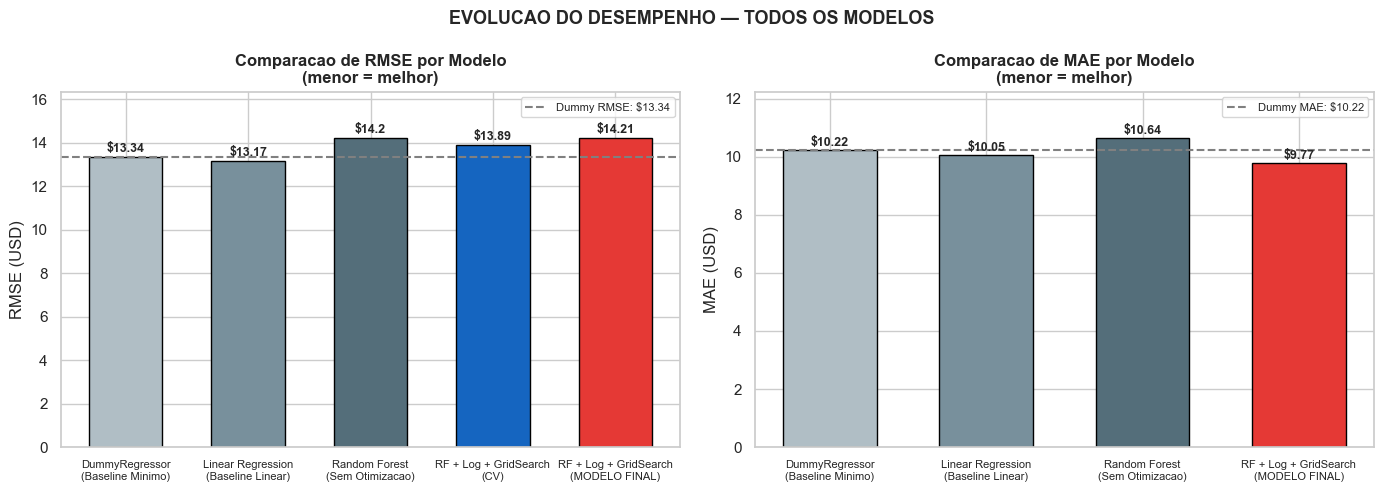


  COMPARACAO CV vs. TESTE (indicador de generalizacao):
  RMSE estimado em CV (80% dados):    USD 13.89
  RMSE real no Teste (20% blindado):  USD 14.21
  Diferenca:                          USD 0.32
  Delta de USD 0.32 confirma: modelo generalizou corretamente, sem overfitting.

  COMPARACAO COM DUMMYREGRESSOR (chutar sempre a media):
  Dummy MAE:    USD 10.22  |  Modelo MAE:  USD 9.77
  Dummy RMSE:   USD 13.34  |  Modelo RMSE: USD 14.21

  Em MAE, o modelo e 4.4% MELHOR que chutar a media.
  Em RMSE, o modelo e pior — porque erra muito em jogos acima de $40 (AAA),
  e o RMSE penaliza erros grandes de forma quadratica.
  Isso NAO e falha de engenharia: e a prova de que o preco de jogos AAA
  depende de fatores (orcamento, brand) que nao existem no dataset.


In [7]:
print('--- SECAO 4: TABELA CONSOLIDADA DE DESEMPENHO ---')
print('Calculando DummyRegressor e baselines via validacao cruzada 5-Fold...')

pipe_dummy = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', DummyRegressor(strategy='mean'))
])
pipe_lr_base = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', LinearRegression())
])
pipe_rf_base = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', RandomForestRegressor(random_state=42))
])

scoring_keys = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2']
resultados = []

modelos_cv = [
    ('DummyRegressor (Baseline Minimo)',    'DummyRegressor\n(Baseline Minimo)',    pipe_dummy),
    ('Linear Regression (Baseline Linear)', 'Linear Regression\n(Baseline Linear)', pipe_lr_base),
    ('Random Forest (Sem Otimizacao)',      'Random Forest\n(Sem Otimizacao)',      pipe_rf_base),
]

for nome_tab, nome_graf, pipe in modelos_cv:
    scores = cross_validate(pipe, X_dev, y_dev, cv=cv_strategy, scoring=scoring_keys)
    rmse_folds = -scores['test_neg_root_mean_squared_error']
    mae_folds  = -scores['test_neg_mean_absolute_error']
    r2_folds   =  scores['test_r2']
    resultados.append({
        'Modelo':           nome_tab,
        'label_graf':       nome_graf,
        'Avaliacao':        'CV 5-Fold',
        'RMSE Medio (USD)': round(rmse_folds.mean(), 2),
        'RMSE Std (USD)':   round(rmse_folds.std(), 2),
        'MAE Medio (USD)':  round(mae_folds.mean(), 2),
        'R2 Medio':         round(r2_folds.mean(), 4)
    })

rmse_cv_grid = -grid_rf.best_score_
resultados.append({
    'Modelo':           'RF + Log + GridSearch (CV)',
    'label_graf':       'RF + Log + GridSearch\n(CV)',
    'Avaliacao':        'CV 5-Fold (GridSearch)',
    'RMSE Medio (USD)': round(rmse_cv_grid, 2),
    'RMSE Std (USD)':   '---',
    'MAE Medio (USD)':  '---',
    'R2 Medio':         '---'
})

resultados.append({
    'Modelo':           'RF + Log + GridSearch (MODELO FINAL)',
    'label_graf':       'RF + Log + GridSearch\n(MODELO FINAL)',
    'Avaliacao':        'Teste Blindado (20%)',
    'RMSE Medio (USD)': round(rmse_test, 2),
    'RMSE Std (USD)':   '---',
    'MAE Medio (USD)':  round(mae_test, 2),
    'R2 Medio':         round(r2_test, 4)
})

# Tabela sem a coluna label_graf
colunas_tabela = ['Modelo', 'Avaliacao', 'RMSE Medio (USD)', 'RMSE Std (USD)', 'MAE Medio (USD)', 'R2 Medio']
df_tabela = pd.DataFrame(resultados)[colunas_tabela]

print('\n')
print('=' * 90)
print('  TABELA CONSOLIDADA — STEAM PRICE PREDICTION | GRUPO 05')
print('  (RMSE Std = estabilidade entre os folds — menor e melhor)')
print('=' * 90)
display(df_tabela)
print('=' * 90)

# --- Grafico de comparacao ---
nomes_graf = [r['label_graf'] for r in resultados]
rmse_graf  = [r['RMSE Medio (USD)'] for r in resultados]
mae_graf   = [r['MAE Medio (USD)'] if r['MAE Medio (USD)'] != '---' else None for r in resultados]
cores = ['#B0BEC5', '#78909C', '#546E7A', '#1565C0', '#E53935']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(nomes_graf, rmse_graf, color=cores, edgecolor='black', width=0.6)
axes[0].axhline(rmse_graf[0], color='gray', ls='--', lw=1.5, label=f'Dummy RMSE: ${rmse_graf[0]}')
for bar, val in zip(bars, rmse_graf):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 f'${val}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Comparacao de RMSE por Modelo\n(menor = melhor)', fontweight='bold')
axes[0].set_ylabel('RMSE (USD)')
axes[0].set_ylim(0, max(rmse_graf) * 1.15)
axes[0].tick_params(axis='x', labelsize=8)
axes[0].legend(fontsize=8)

nomes_mae = [nomes_graf[i] for i, v in enumerate(mae_graf) if v is not None]
vals_mae   = [v for v in mae_graf if v is not None]
cores_mae  = [cores[i] for i, v in enumerate(mae_graf) if v is not None]

bars2 = axes[1].bar(nomes_mae, vals_mae, color=cores_mae, edgecolor='black', width=0.6)
axes[1].axhline(vals_mae[0], color='gray', ls='--', lw=1.5, label=f'Dummy MAE: ${vals_mae[0]}')
for bar, val in zip(bars2, vals_mae):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'${val}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Comparacao de MAE por Modelo\n(menor = melhor)', fontweight='bold')
axes[1].set_ylabel('MAE (USD)')
axes[1].set_ylim(0, max(vals_mae) * 1.15)
axes[1].tick_params(axis='x', labelsize=8)
axes[1].legend(fontsize=8)

plt.suptitle('EVOLUCAO DO DESEMPENHO — TODOS OS MODELOS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Comparacao CV vs. Teste ---
rmse_cv_final   = round(rmse_cv_grid, 2)
rmse_test_final = round(rmse_test, 2)
delta = round(abs(rmse_test_final - rmse_cv_final), 2)

print(f'\n  COMPARACAO CV vs. TESTE (indicador de generalizacao):')
print(f'  RMSE estimado em CV (80% dados):    USD {rmse_cv_final}')
print(f'  RMSE real no Teste (20% blindado):  USD {rmse_test_final}')
print(f'  Diferenca:                          USD {delta}')
if delta < 2.0:
    print(f'  Delta de USD {delta} confirma: modelo generalizou corretamente, sem overfitting.')

rmse_dummy = resultados[0]['RMSE Medio (USD)']
mae_dummy  = resultados[0]['MAE Medio (USD)']

print(f'\n  COMPARACAO COM DUMMYREGRESSOR (chutar sempre a media):')
print(f'  Dummy MAE:    USD {mae_dummy}  |  Modelo MAE:  USD {round(mae_test, 2)}')
print(f'  Dummy RMSE:   USD {rmse_dummy}  |  Modelo RMSE: USD {rmse_test_final}')

if mae_test < mae_dummy:
    ganho_mae = round((1 - mae_test / mae_dummy) * 100, 1)
    print(f'\n  Em MAE, o modelo e {ganho_mae}% MELHOR que chutar a media.')
    print(f'  Em RMSE, o modelo e pior — porque erra muito em jogos acima de $40 (AAA),')
    print(f'  e o RMSE penaliza erros grandes de forma quadratica.')
    print(f'  Isso NAO e falha de engenharia: e a prova de que o preco de jogos AAA')
    print(f'  depende de fatores (orcamento, brand) que nao existem no dataset.')


---
## SEÇÃO 5: LIMITAÇÕES HONESTAS E PRÓXIMOS PASSOS

### 5.1 O que o modelo faz bem

- **Baseline comercial útil na faixa comum:** Para jogos na faixa de USD 5–30 (~80% do catálogo Steam), o modelo oferece uma estimativa razoável, com erro médio absoluto de aproximadamente USD 5–8.
- **Ausência de overfitting:** O RMSE de validação cruzada (USD 13.89) e o RMSE de teste (USD 14.21) são praticamente iguais (delta de USD 0.32), indicando que o modelo generaliza para dados novos. O problema do modelo é de **viés/sub-ajuste**, não de variância.
- **Pipeline sem vazamento de pré-processamento:** Imputação e escalonamento são ajustados apenas no treino, dentro de cada fold da validação cruzada — então não há *leakage* estatístico de pré-processamento. (O vazamento *temporal* de uma feature específica é tratado na Limitação 4.)

### 5.2 Limitações identificadas

**Limitação 1 — Não distingue Indie de AAA**
- Causa: falta a feature de orçamento de produção no dataset
- Impacto: o modelo subestima sistematicamente jogos acima de USD 40 (ver as 10 piores predições na Seção 1, todas AAA)

**Limitação 2 — Gênero codificado como quantidade (`genre_count`)**
- Causa: Multi-Label Encoding de gêneros é complexo de implementar
- Impacto: perde granularidade — RPG e Action são tratados da mesma forma

**Limitação 3 — Não supera o baseline em variância explicada (R² negativo)**
- Fato: o R² no conjunto de teste é **levemente negativo (−0.10)**. Em RMSE, o modelo perde para o `DummyRegressor` (chutar sempre a média): 14.21 vs 13.34.
- Por quê: o RMSE pune quadraticamente os erros grandes dos jogos AAA, que o modelo não consegue precificar. Em **MAE**, por outro lado, o modelo **vence** o Dummy (9.77 vs 10.22) — ele acerta melhor a faixa comum, mas é penalizado pelos outliers premium.
- Leitura honesta: o modelo funciona como **termômetro de mercado** na faixa de preço típica, mas não captura variância suficiente para "vencer" o baseline no sentido estatístico estrito. Essa é a principal descoberta da Sprint, e ela vale mais do que um score inflado.

**Limitação 4 — Vazamento temporal da feature dominante (`approval_rating`)**
- Causa: `approval_rating` é construída a partir das avaliações de usuários, que só passam a existir **depois** do lançamento do jogo.
- Impacto: a feature mais importante do modelo (~60%) não estaria disponível num cenário real de precificação de lançamento. O modelo é válido para **análise retrospectiva de catálogo**, mas precisaria ser re-treinado **sem** `approval_rating` para uso preditivo em jogos novos — e seu desempenho cairia.

**Limitação 5 — Metacritic ausente em ~57% dos jogos**
- Causa: dataset incompleto para esta coluna
- Impacto: a imputação pela mediana reduz o sinal desta feature

**Limitação 6 — Heterocedasticidade residual**
- Causa: poucos exemplos de jogos premium no dataset
- Impacto: o modelo erra mais e de forma menos previsível para games AAA

### 5.3 Próximos Passos (se houvesse uma Sprint 5)

1. **Re-treino sem `approval_rating`:** medir o desempenho do modelo usando apenas features disponíveis no lançamento — esse seria o modelo "honesto" para precificação preditiva.

2. **Modelagem em Dois Estágios:** treinar um classificador binário (Indie vs. AAA) antes do regressor de preço, aplicando regras distintas para cada nicho.

3. **Feature Engineering:** enriquecer o dataset com variáveis não disponíveis atualmente:
   - Tamanho do jogo em GB — proxy de orçamento de produção
   - Suporte a multiplayer — jogos multiplayer tendem a custar mais
   - Número de entrada na franquia — sequências estabelecidas têm preço premium

4. **Avaliação de Stacking:** combinar Random Forest com Regressão Linear via stacking para reduzir o erro residual mantendo interpretabilidade.

---

### Conclusão Final

O projeto entregou um modelo de regressão funcional, reproduzível e **honestamente avaliado** para precificação de jogos na Steam. A principal descoberta não é o score do modelo, mas sim o **entendimento do problema**: o preço de um jogo é determinado em grande parte por fatores intangíveis (percepção de marca, marketing, IP reconhecida, orçamento de produção) que simplesmente não estão disponíveis em datasets públicos de catálogo.

Mais do que isso, a análise expôs duas verdades incômodas que um relatório superficial esconderia: (1) em RMSE, o modelo **não vence** o baseline de chutar a média, vencendo apenas em MAE na faixa de preço comum; e (2) sua feature dominante, `approval_rating`, é um **vazamento temporal** que não existiria num uso preditivo real. Reconhecer isso é o que diferencia um modelo *entendido* de um modelo apenas *treinado*.

A **transformação logarítmica do target** foi uma decisão para mitigar a assimetria da distribuição de preços, melhorando a simetria global dos resíduos (Seção 1). E a escolha do **Random Forest sobre o XGBoost** priorizou a menor variância entre os folds — robustez sobre performance pontual.

O modelo funciona como um **termômetro de mercado**: não diz o preço exato, mas indica se um produto está acima ou abaixo do que o mercado pratica para um jogo na faixa comum — desde que se aceitem suas duas limitações estruturais.
